In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import uniform, randint

plt.rcParams["font.size"] = 16

# Preprocessing
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Model selection
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)

# Pipeline
from sklearn.pipeline import Pipeline, make_pipeline

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

_Type your answer here, replacing this text._

In [3]:
raw_data = pd.read_csv("data/UCI_Credit_Card.csv")

**Initial Thoughts**
- The credit card default classifier is more interesting to me as in the fall I built a model for a hackathon that tried to predict if a business would close in the event of economic recession. Using ML models to determine financial outcomes it quite interesting to me.
- The problem seems rather straightforward. I am going to determine appropriate predictors to classify the default.payment.next.month target variable.
- My workflow will be preprocessing, training/test split, and finally hyperparameter optimizations. Even though this assignment project oriented, I will implement an ensemble model to stay consitent with the learning outcomes we have seen in lecture and tutorial. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
random_state =123
train_df,test_df = train_test_split(raw_data,test_size = 0.7, random_state = 123)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

In [5]:
# I want to see the spread of the limit ballance, specifically the IQR as I predict there will be a very large range (lots of outliers on the lower and upper bound of the data)
column_info = raw_data.columns
limit_bal_stats = raw_data["LIMIT_BAL"].describe()
ratios = raw_data["default.payment.next.month"].value_counts(normalize=True)
missing_counts = raw_data.isna().sum()

print(ratios)
print(limit_bal_stats)
print(column_info)
print(missing_counts)


default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64
count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                 

**Key notes on the types of data:**
- There are no non-null values, so imputation will not be required
- Data points are a mix of categorical and quantative
- Pay_i = Repayment status in [September, August, July, June, May, April] 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
- Need to see how good of a predictor repayment status, marital status, education, age, bill amount, and pay amount are (across those same months). \
  
**Key notes on the spread of the data:**
- The limit ballance is slightly skewed right, this is expected as large credits will have a larger impact on the average than a bunch of smaller credits
- Below I have created visualizations for each predictor, distributed with respect to the credit default status to show how well of an indicator that predictor will be. If the spreads mostly overlap I will not include that predictor. 

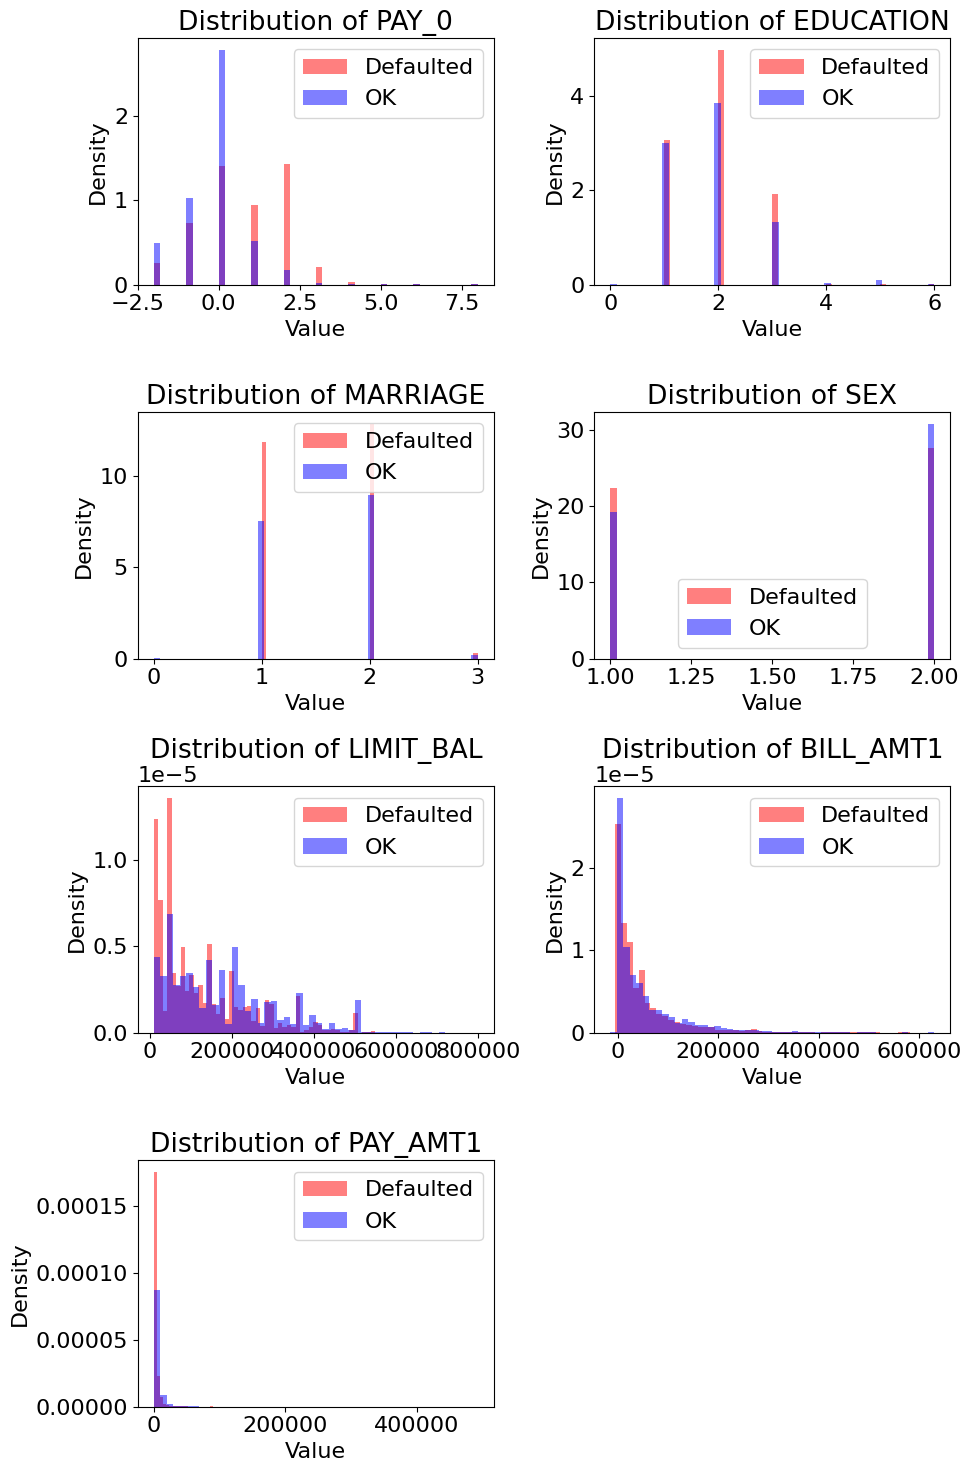

In [6]:
cols = ["PAY_0","EDUCATION","MARRIAGE","SEX","LIMIT_BAL", "BILL_AMT1","PAY_AMT1"]
target = "default.payment.next.month"
df_default = train_df[train_df[target] == 1]
df_ok = train_df[train_df[target] == 0]
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 15))

# CREDIT CHATGPT FOR GRID LOGIC: Previosly I was using the list logic given in HW3 Question 1.3 but it resulted in an unfriendly viewing experience.
axes = axes.flatten() # Flatten so we can iterate with a single index

for i, col in enumerate(cols):
    ax = axes[i]
    
    # Plotting into the specific 'ax'
    df_default[col].plot.hist(ax=ax, bins=50, alpha=0.5, label='Defaulted', color='red', density=True)
    df_ok[col].plot.hist(ax=ax, bins=50, alpha=0.5, label='OK', color='blue', density=True)
    
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

# 4. Cleanup: Hide the empty 8th subplot
if len(cols) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

These are the PDFs of each predictor under the constraints of the target variable and let us know how likely the data is to fall into the bin (either defaulted or ok). This data set is rather nice in that all of the predictors have enough variation to qualify them as discriminatory features and should therefore be used. Also, if there are features that introduce too much noise, RFECV feature engineering will handle it.\
**Metrics** \
As this is a classification model, I will use accuracy, and F1 score. These will be presented together, but I suspect F1 score to be the most insightful, as F1 is the harmonic mean of accuracy and precision, and accuracy can be a poor metric with class imbalance (0.77 no default and 0.23 default).

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

- One-hot encode categorical data
- Scale numeric data
- Drop ID as it is not relevent
- Imputation is not needed as there are no NA values

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [7]:
edu_map = {
    0: 0, 5: 0, 6: 0, 4: 0, # All unkowns become 0
    3: 1,                   # High school
    2: 2,                   # University
    1: 3                    # Graduate school
}

train_df["EDUCATION"] = train_df["EDUCATION"].map(edu_map)
test_df["EDUCATION"] = test_df["EDUCATION"].map(edu_map)

In [8]:
categorical_features = ["MARRIAGE"]
numeric_features = ["EDUCATION","LIMIT_BAL","AGE",
                    "PAY_AMT1","PAY_AMT2",
                    "PAY_AMT3","PAY_AMT4",
                    "PAY_AMT5","PAY_AMT6",
                    "BILL_AMT1","BILL_AMT2",
                   "BILL_AMT3","BILL_AMT4",
                   "BILL_AMT5","BILL_AMT6",
                   "PAY_0","PAY_2",
                        "PAY_3","PAY_4",
                        "PAY_5","PAY_6"]
binary_features = ["SEX"]
drop_features = ["ID"]
target_features = ["default.payment.next.month"]

In [9]:
numeric_transformer = StandardScaler()
ordinal_transformer = OrdinalEncoder(dtype=int)
binary_transformer = OneHotEncoder(drop="if_binary", dtype=int)
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features,),  
    (binary_transformer,binary_features),  
    (categorical_transformer, categorical_features),  
    ("drop", drop_features))

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [10]:
# Function pulled from homework 3

def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    """
    Returns mean and std of cross validation

    Parameters
    ----------
    model :
        scikit-learn model
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    scores = cross_validate(model, X_train, y_train, **kwargs)

    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

In [11]:
results_dict = {}

X_train = train_df.drop(columns=["default.payment.next.month"])
y_train = train_df["default.payment.next.month"]

dummy = DummyClassifier(strategy="stratified", random_state=123)
pipe = make_pipeline(preprocessor, dummy)

scoring = {
    "f1": "f1",
    "accuracy": "accuracy"
}

results_dict["dummy"] = mean_std_cross_val_scores(
    pipe,
    X_train,
    y_train,
    return_train_score=True,
    scoring=scoring
)

In [12]:
results_baseline = pd.DataFrame(results_dict).T
results_baseline

,fit_time,score_time,test_f1,train_f1,test_accuracy,train_accuracy
dummy,0.012 (+/- 0.002),0.007 (+/- 0.000),0.225 (+/- 0.015),0.231 (+/- 0.004),0.649 (+/- 0.007),0.658 (+/- 0.002)


Our baseline F1 is 0.225 and our baseline accuracy is 0.649. Any improvements to these scores indicate that our model preforms better than a frequentist classifier.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

I will be training a Logistic Regression and tuning values for C.

In [13]:
pipeLogReg = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, C=3, random_state=123)
)

scoring = {
    "f1": "f1",
    "accuracy": "accuracy"
}

results_dict["LogisticRegression"] = mean_std_cross_val_scores(
    pipeLogReg,
    X_train,
    y_train,
    cv=5,
    return_train_score=True,
    scoring=scoring
)

In [14]:
results_df = pd.DataFrame(results_dict).T
results_df

,fit_time,score_time,test_f1,train_f1,test_accuracy,train_accuracy
dummy,0.012 (+/- 0.002),0.007 (+/- 0.000),0.225 (+/- 0.015),0.231 (+/- 0.004),0.649 (+/- 0.007),0.658 (+/- 0.002)
LogisticRegression,0.037 (+/- 0.009),0.007 (+/- 0.001),0.398 (+/- 0.035),0.397 (+/- 0.017),0.812 (+/- 0.009),0.812 (+/- 0.003)


**Hyperparameter Optimization**

In [15]:
train_f1 = []
valid_f1 = []

train_acc = []
valid_acc = []

C_vals = 10.0 ** np.arange(-1.5, 2, 0.5)

for C in C_vals:
    pipe = make_pipeline(
        preprocessor,
        LogisticRegression(max_iter=1000, C=C, random_state=123),
    )

    cv_results = cross_validate(
        pipe,
        X_train,
        y_train,
        return_train_score=True,
        scoring={"f1": "f1", "accuracy": "accuracy"},
    )

    train_f1.append(cv_results["train_f1"].mean())
    valid_f1.append(cv_results["test_f1"].mean())

    train_acc.append(cv_results["train_accuracy"].mean())
    valid_acc.append(cv_results["test_accuracy"].mean())

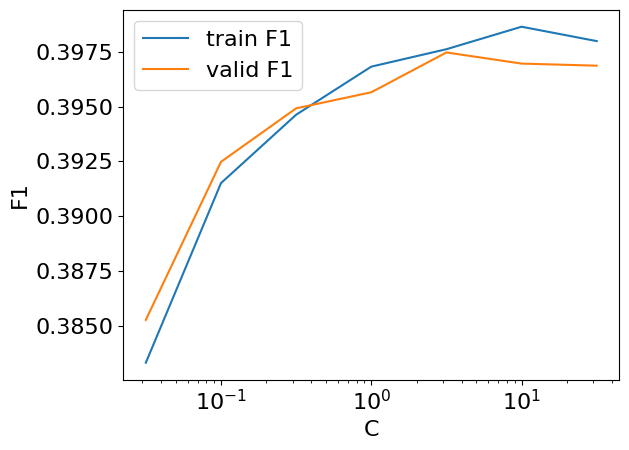

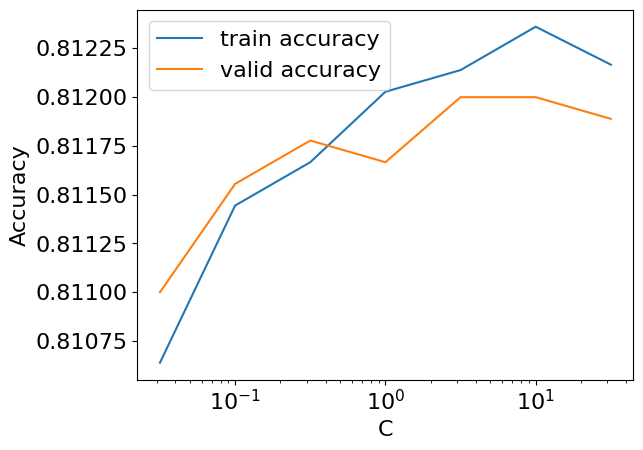

In [16]:
plt.semilogx(C_vals, train_f1, label="train F1")
plt.semilogx(C_vals, valid_f1, label="valid F1")
plt.legend()
plt.xlabel("C")
plt.ylabel("F1")
plt.show()

plt.semilogx(C_vals, train_acc, label="train accuracy")
plt.semilogx(C_vals, valid_acc, label="valid accuracy")
plt.legend()
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.show()

In [17]:
scoring_metric = "f1"

param_grid = {
    "logisticregression__C": C_vals
}

pipe = make_pipeline(preprocessor,
        LogisticRegression(max_iter=1000, C=C, random_state=123),
    )
grid_search = GridSearchCV(pipe,
                           param_grid = param_grid,
                           scoring=scoring_metric,
                           n_jobs =-1,
                           return_train_score = True)

grid_search.fit(X_train,y_train)
best_C = grid_search.best_params_["logisticregression__C"]
best_score = grid_search.best_score_

In [18]:
results_df = pd.DataFrame({
    "C": C_vals,
    "train_f1": train_f1,
    "valid_f1": valid_f1,
    "train_accuracy": train_acc,
    "valid_accuracy": valid_acc,
})

best_f1_idx = results_df["valid_f1"].idxmax()
best_acc_idx = results_df["valid_accuracy"].idxmax()

best_results = pd.DataFrame({
    "Metric": ["F1", "Accuracy"],
    "Best C": [
        results_df.loc[best_f1_idx, "C"],
        results_df.loc[best_acc_idx, "C"]
    ],
    "Validation Score": [
        results_df.loc[best_f1_idx, "valid_f1"],
        results_df.loc[best_acc_idx, "valid_accuracy"]
    ],
    "Train Score": [
        results_df.loc[best_f1_idx, "train_f1"],
        results_df.loc[best_acc_idx, "train_accuracy"]
    ]
})

best_results

,Metric,Best C,Validation Score,Train Score
0,F1,3.162278,0.397468,0.397616
1,Accuracy,3.162278,0.812000,0.812139


**Findings**
- The best values for C is 3.16. This value gives us the best f1 score and the best accuracy. The standard deviation of the cross-validation accuracy is 0.009 and 0.007 for the f1. The accuracy saw an increase in 0.16, landing at a value of 0.812 from our baseline of 0.65. Our score went from 0.225 to 0.397.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

In [19]:
pipe_xgb = make_pipeline(
    preprocessor,
    XGBClassifier(
        random_state=123,
        verbosity=0,
        use_label_encoder=False,
        eval_metric="logloss"  
    ),
)

pipe_rf = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        class_weight="balanced",
        random_state=123
    ),
)

pipe_sklearn_histGB = make_pipeline(
    preprocessor,
    HistGradientBoostingClassifier(
        random_state=123
    ),
)

classifiers = {
    "random forest": pipe_rf,
    "XGBoost": pipe_xgb,
    "sklearn_histGB": pipe_sklearn_histGB
}

scoring = {
    "f1": "f1",
    "accuracy": "accuracy"
}

results = {}

for name, model in classifiers.items():
    results[name] = mean_std_cross_val_scores(
        model,
        X_train,
        y_train,
        return_train_score=True,
        scoring=scoring
    )

In [20]:
results_before_tune = pd.DataFrame(results).T
results_before_tune

,fit_time,score_time,test_f1,train_f1,test_accuracy,train_accuracy
random forest,1.459 (+/- 0.141),0.037 (+/- 0.002),0.461 (+/- 0.017),0.999 (+/- 0.000),0.813 (+/- 0.006),0.999 (+/- 0.000)
XGBoost,0.107 (+/- 0.005),0.011 (+/- 0.001),0.471 (+/- 0.026),0.895 (+/- 0.012),0.807 (+/- 0.010),0.957 (+/- 0.005)
sklearn_histGB,0.761 (+/- 0.960),0.020 (+/- 0.009),0.483 (+/- 0.019),0.702 (+/- 0.003),0.816 (+/- 0.005),0.891 (+/- 0.002)


**Results**
- The random forest and sklean Gradient Boosted Decision Tree both outperformed the linear classification (without optimized hyperparameters) in both accuracy and f1 score. The XGBoost had a better f1 than our Logistic Regression but worse accuracy, as we have discussed above, f1 is a more important metric as it is more representative (and our data is a bit unbalanced).
- Compared to the linear model, our best non-linear model saw an accuracy increase in 0.04. Where we saw the most improvement was in f1 score, jumping from 0.397 (linear model) to 0.483 (gradient boosted tree).

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

In [21]:
from sklearn.feature_selection import RFECV

X_train_preprocessed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()


selector = RFECV(
    estimator=RandomForestClassifier(n_estimators=50, random_state=123),
    step=1,
    cv=5,
    scoring=scoring_metric
)

selector.fit(X_train_preprocessed, y_train)

best_features = feature_names[selector.support_]

print(f"Selected {len(best_features)} features out of {len(feature_names)}")
print("Features kept:", best_features)

Selected 20 features out of 26
Features kept: ['standardscaler__LIMIT_BAL' 'standardscaler__AGE'
 'standardscaler__PAY_AMT1' 'standardscaler__PAY_AMT2'
 'standardscaler__PAY_AMT3' 'standardscaler__PAY_AMT4'
 'standardscaler__PAY_AMT5' 'standardscaler__PAY_AMT6'
 'standardscaler__BILL_AMT1' 'standardscaler__BILL_AMT2'
 'standardscaler__BILL_AMT3' 'standardscaler__BILL_AMT4'
 'standardscaler__BILL_AMT5' 'standardscaler__BILL_AMT6'
 'standardscaler__PAY_0' 'standardscaler__PAY_2' 'standardscaler__PAY_3'
 'standardscaler__PAY_4' 'standardscaler__PAY_5' 'standardscaler__PAY_6']


In [22]:
X_train_reduced = X_train_preprocessed[:, selector.support_]

reduced_cv_results = cross_validate(
    RandomForestClassifier(n_estimators=50, random_state=123), 
    X_train_reduced, 
    y_train, 
    cv=5, 
    scoring=scoring_metric,
    return_train_score=True
)

reduced_df = pd.DataFrame(reduced_cv_results)
print("Mean Reduced Test F1 Score:", reduced_df["test_score"].mean())

Mean Reduced Test F1 Score: 0.48288994458164003


We cannot perform RFCEV on HistGB, later we look at the SHAP of HistGB. It is worth noting that the f1 score after removing 6 features increased by 0.02, which is quite significant, but it still does not beat the HistGB scores.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

For the rest of the tuning, I will be tuning for F1 score. In previous findings, F1 score and accuracy are positivly correlated. Because of F1 is a more representative metric, I will be optimizing for f1 and then in the final testing stage of the ML process I will evaluate a multitude of different metrics.

In [23]:
param_grid = {
    "randomforestclassifier__n_estimators": [50, 100, 200],
    "randomforestclassifier__max_depth": [10, 20, None], # None means grow until leaf is pure
    "randomforestclassifier__max_features": [5, 10, 20, "sqrt"] 
}

grid_search = GridSearchCV(
    pipe_rf,
    param_grid=param_grid,
    n_jobs=-1,
    return_train_score=True,
    scoring=scoring_metric
)



In [24]:
grid_search.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': [10, 20, ...], 'randomforestclassifier__max_features': [5, 10, ...], 'randomforestclassifier__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

In [25]:
best_max_features = grid_search.best_params_["randomforestclassifier__max_features"]
best_max_depth = grid_search.best_params_["randomforestclassifier__max_depth"]
best_n_estimators = grid_search.best_params_["randomforestclassifier__n_estimators"]
best_score = grid_search.best_score_
print(f"Optimized feature number:{best_max_features}")
print(f"Optimized depth: {best_max_depth}")
print(f"Optimized estimator number: {best_n_estimators}")
print(f"Best score: {best_score}")

Optimized feature number:5
Optimized depth: 10
Optimized estimator number: 100
Best score: 0.5380677412642709


In [26]:
param_dist_hgb = {
    "histgradientboostingclassifier__max_iter": randint(50, 300),
    "histgradientboostingclassifier__max_depth": [3, 5, 10, None],
}

random_search_hgb = RandomizedSearchCV(
    pipe_sklearn_histGB,
    param_distributions=param_dist_hgb,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring=scoring_metric, 
    random_state=123,
    return_train_score=True
)
random_search_hgb.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'histgradientboostingclassifier__max_depth': [3, 5, ...], 'histgradientboostingclassifier__max_iter': <scipy.stats....00215B02FCAD0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

In [27]:
best_max_iter = random_search_hgb.best_params_["histgradientboostingclassifier__max_iter"]
best_max_depth = random_search_hgb.best_params_["histgradientboostingclassifier__max_depth"]
best_score = random_search_hgb.best_score_
print(f"Optimized feature number:{best_max_iter}")
print(f"Optimized depth: {best_max_depth}")
print(f"Best score: {best_score}")

Optimized feature number:258
Optimized depth: 3
Best score: 0.4921419819922498


In [28]:
param_dist_xgb = {
    "xgbclassifier__n_estimators": randint(50, 300),
    "xgbclassifier__max_depth": randint(3, 10),
    "xgbclassifier__scale_pos_weight": [1, 3, 5] 
}

random_search_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring="f1",
    random_state=123,
    return_train_score=True
)

random_search_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgbclassifier__max_depth': <scipy.stats....00215AFDF1A90>, 'xgbclassifier__n_estimators': <scipy.stats....00215AFDF3D90>, 'xgbclassifier__scale_pos_weight': [1, 3, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validat

In [29]:
best_max_iter = random_search_xgb.best_params_["xgbclassifier__n_estimators"]
best_max_depth = random_search_xgb.best_params_["xgbclassifier__max_depth"]
best_weight = random_search_xgb.best_params_["xgbclassifier__scale_pos_weight"]
best_score = random_search_hgb.best_score_
print(f"Optimized feature number: {best_max_iter}")
print(f"Optimized depth: {best_max_depth}")
print(f"Optimized weight: {best_weight}")
print(f"Best score: {best_score}")

Optimized feature number: 118
Optimized depth: 3
Optimized weight: 3
Best score: 0.4921419819922498


In [30]:
final_comparison = {
    "Model": ["Random Forest", "HistGB", "XGBoost"],
    "Best F1 Score": [
        grid_search.best_score_, 
        random_search_hgb.best_score_, 
        random_search_xgb.best_score_
    ]
}
print("Results before tune:")
display(results_before_tune)
print("Results after tune:")
pd.DataFrame(final_comparison).sort_values(by="Best F1 Score", ascending=False)

Results before tune:


,fit_time,score_time,test_f1,train_f1,test_accuracy,train_accuracy
random forest,1.459 (+/- 0.141),0.037 (+/- 0.002),0.461 (+/- 0.017),0.999 (+/- 0.000),0.813 (+/- 0.006),0.999 (+/- 0.000)
XGBoost,0.107 (+/- 0.005),0.011 (+/- 0.001),0.471 (+/- 0.026),0.895 (+/- 0.012),0.807 (+/- 0.010),0.957 (+/- 0.005)
sklearn_histGB,0.761 (+/- 0.960),0.020 (+/- 0.009),0.483 (+/- 0.019),0.702 (+/- 0.003),0.816 (+/- 0.005),0.891 (+/- 0.002)


Results after tune:


,Model,Best F1 Score
0,Random Forest,0.538068
2,XGBoost,0.533706
1,HistGB,0.492142


## Model Performance Summary

**Before Tuning** 

Before hyperparameter tuning, HistGradientBoosting (HistGB) achieved the highest validation F1 score (0.483), followed by XGBoost (0.471) and Random Forest (0.461).

Random Forest showed severe overfitting (train = 0.999 vs test = 0.461), while XGBoost showed moderate overfitting. HistGB had the smallest train–test gap, indicating better generalization.

**After Tuning**

After tuning, performance improved substantially:

- **Random Forest:** 0.538 (best)
- **XGBoost:** 0.534
- **HistGB:** 0.492

Random Forest benefited the most from tuning and achieved the highest F1 score overall. HistGB improved only slightly, suggesting it was already near optimal.

Although HistGB generalized best before tuning, the tuned Random Forest achieved the strongest overall performance and would be selected as the final model.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [31]:
best_rf = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        max_features=5,
        class_weight="balanced",
        random_state=123
    )
)

best_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder-1', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

In [32]:
import shap

rf_model = best_rf.named_steps["randomforestclassifier"]

X_train_transformed = best_rf.named_steps["columntransformer"].transform(X_train)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train_transformed)

# ChatGPT helped me with this, there is a new version of SHAP that I was unaware of
if len(shap_values.shape) == 3:
    shap_class1 = shap_values[:, :, 1]   
else:
    shap_class1 = shap_values[1]         

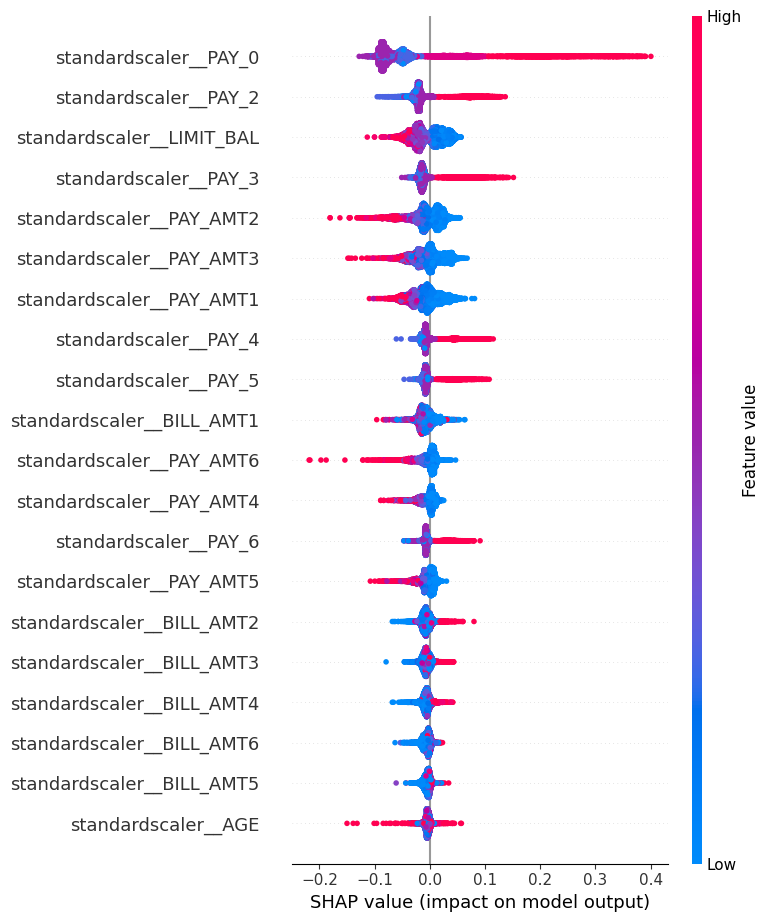

In [33]:
feature_names = best_rf.named_steps["columntransformer"].get_feature_names_out()

shap.summary_plot(
    shap_class1,
    X_train_transformed,
    feature_names=feature_names
)

The repayment status in September has a huge impact on the classification of the target variable. The amount on the bill statement across all months is quite low. I suspected this and almost did not include it, if we look at the distributions in the EDA phase, we can see that bill amount has the most overlap. But across the board, the features did a good job predicting the model output (we see mostly red tones in SHAP output)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


final_model = best_rf.fit(X_train,y_train)

X_test = test_df.drop(columns=["default.payment.next.month"])
y_test = test_df["default.payment.next.month"]
y_pred = final_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [35]:
results_baseline

,fit_time,score_time,test_f1,train_f1,test_accuracy,train_accuracy
dummy,0.012 (+/- 0.002),0.007 (+/- 0.000),0.225 (+/- 0.015),0.231 (+/- 0.004),0.649 (+/- 0.007),0.658 (+/- 0.002)


In [36]:
test_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Score": [accuracy, precision, recall, f1]
})

test_results

,Metric,Score
0,Accuracy,0.796619
1,Precision,0.536559
2,Recall,0.532248
3,F1,0.534394


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

## Key Results Summary 

### Model Comparison (Validation Performance)

| Model               | Best Validation F1 | Notes |
|---------------------|-------------------|-------|
| Random Forest (tuned) | **0.538** | Largest improvement after tuning |
| XGBoost (tuned)        | 0.534 | Strong performance, computationally efficient |
| HistGradientBoosting   | 0.492 | Most stable before tuning |
| Dummy Baseline         | 0.225 | Majority-class baseline |

**Key observations:**
- All non-linear models significantly outperformed the dummy baseline.
- Random Forest showed severe overfitting before tuning but improved dramatically after hyperparameter optimization.
- HistGradientBoosting generalized best before tuning but benefited less from hyperparameter search.
- Tuning was critical for Random Forest performance.

---

## Final Test Results (Selected Model: Tuned Random Forest)

| Metric     | Score |
|------------|--------|
| Accuracy   | 0.797 |
| Precision  | 0.537 |
| Recall     | 0.532 |
| **F1 Score** | **0.534** |

The primary evaluation metric was **F1 score**, as the dataset is imbalanced and F1 balances precision and recall.

---

## Concluding Remarks

- Hyperparameter tuning substantially improved Random Forest performance.
- Tree-based ensemble methods performed well for this classification task.
- The final model achieved strong improvements over baseline and demonstrated balanced precision and recall.
- Feature interpretation (via SHAP) showed that repayment behavior variables were the most influential predictors, aligning with domain intuition.
- Tree ensembles inherently handled feature selection effectively, making explicit feature elimination unnecessary.

Overall, the tuned Random Forest provided the best balance between predictive performance and interpretability.

---

## Future Improvements

Potential next steps to improve performance or interpretability include:

- Performing a more extensive hyperparameter search (e.g., Bayesian optimization).
- Trying class imbalance strategies such as SMOTE or adjusting decision thresholds.
- Optimizing the classification threshold specifically for F1 score.
- Exploring probability calibration for better precision–recall trade-offs.
- Comparing performance with neural network models.
- Conducting deeper SHAP analysis for local interpretability.

---

## Final Reported Metric

The final reported metric is:

> **Test F1 Score: 0.534**

This metric was chosen because it provides a balanced evaluation of precision and recall in an imbalanced classification setting.

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

There are so many models available and among them, so many ways to optimize for different metrics. I could not help but think
about how all the little optimizations I could be making that I am just not accounting for, be it the types of models, the metrics I am using, the feature engineering choices...etc. I now realize that to get a wholistic model that generalizes well, it takes a lot of time, and that the process is quite iterative. If something changes in your model in the feature engineering stages or hyperparameter optimizations, it might entirely change the way you approach the problem (perhaps the scores are not what was expected and the chosen model(s) dont represent the data well). Overall, I liked the freedom of this assignment and I found myself far more engaged in the material in a project based context as opposed to a homework sheet.

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)